=== PneumoniaMNIST ===

Dataset: PneumoniaMNIST | Class: Normal (0)


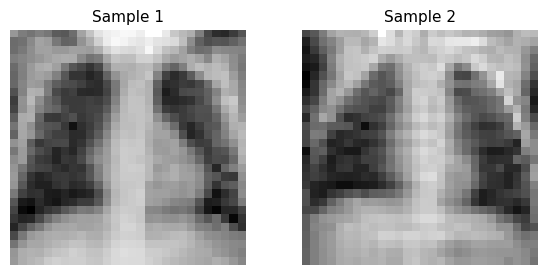


Dataset: PneumoniaMNIST | Class: Pneumonia (1)


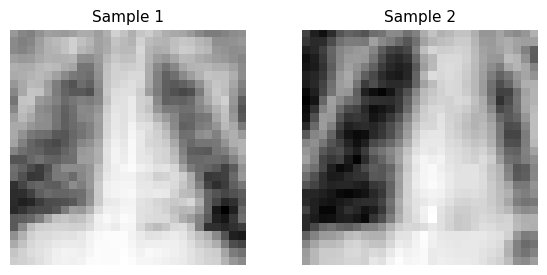


=== DermaMNIST ===

Dataset: DermaMNIST | Class: actinic keratoses (0)


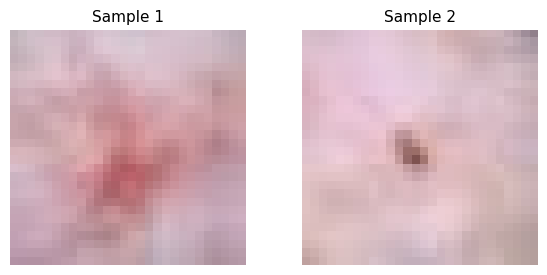


Dataset: DermaMNIST | Class: basal cell carcinoma (1)


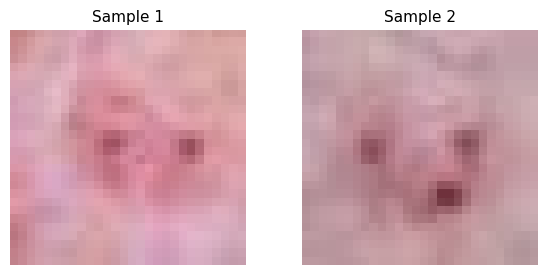


Dataset: DermaMNIST | Class: benign keratosis-like (2)


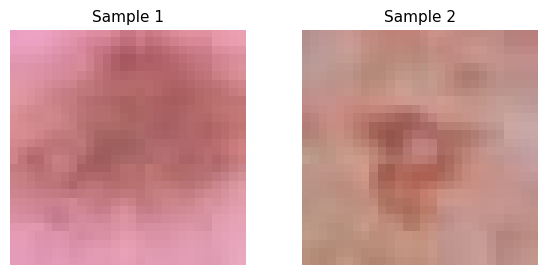


Dataset: DermaMNIST | Class: dermatofibroma (3)


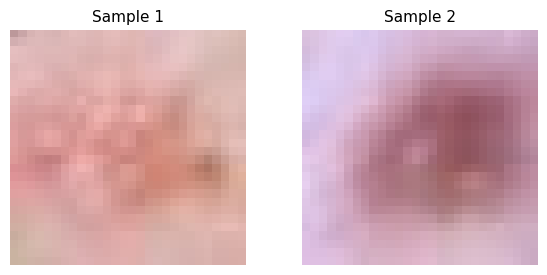


Dataset: DermaMNIST | Class: melanocytic nevi (4)


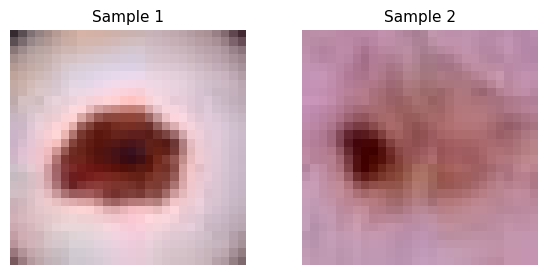


Dataset: DermaMNIST | Class: pyogenic granulomas (5)


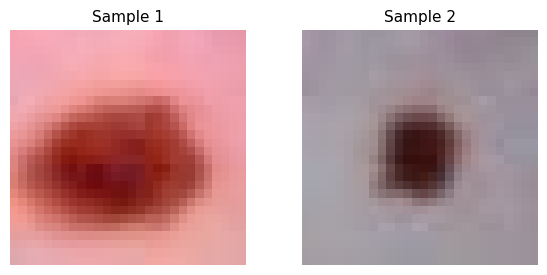


Dataset: DermaMNIST | Class: melanoma (6)


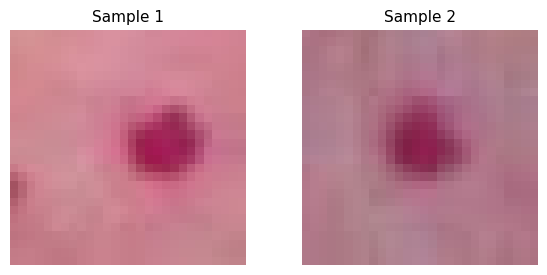


=== BloodMNIST ===

Dataset: BloodMNIST | Class: basophil (0)


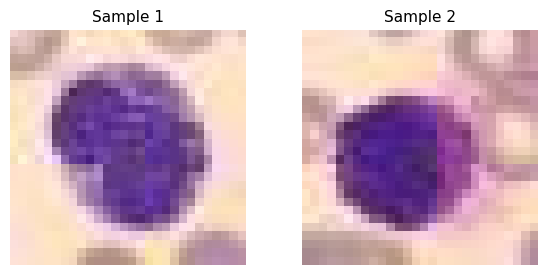


Dataset: BloodMNIST | Class: eosinophil (1)


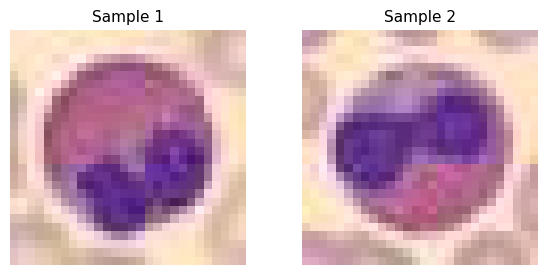


Dataset: BloodMNIST | Class: erythroblast (2)


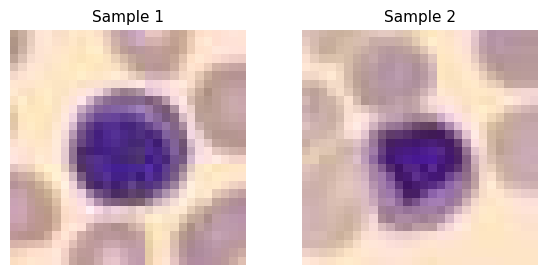


Dataset: BloodMNIST | Class: immature granulocyte (3)


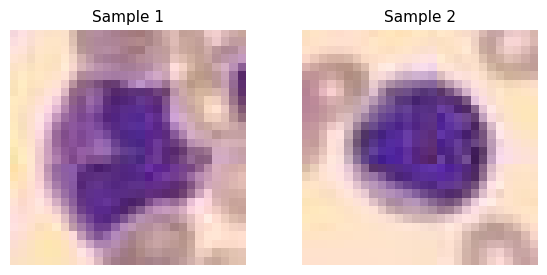


Dataset: BloodMNIST | Class: lymphocyte (4)


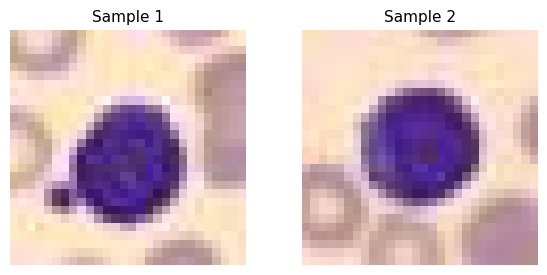


Dataset: BloodMNIST | Class: monocyte (5)


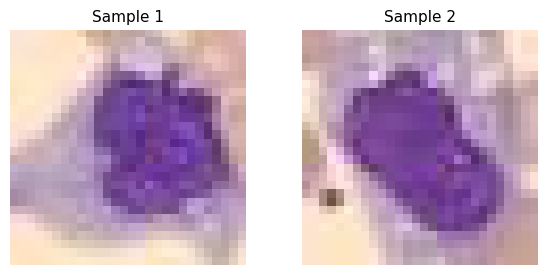


Dataset: BloodMNIST | Class: neutrophil (6)


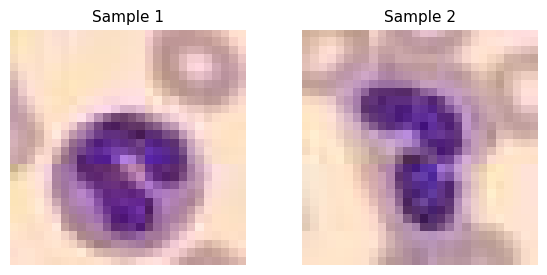


Dataset: BloodMNIST | Class: platelet (7)


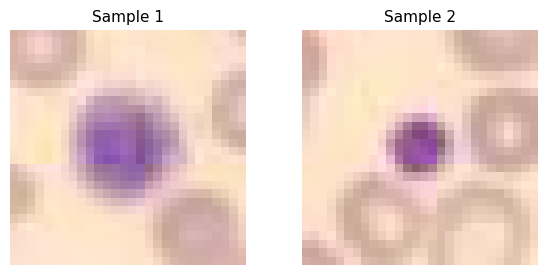

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# 1. Fungsi untuk menampilkan 2 sample per kelas (1 kelas = 1 figure)
# --------------------------------------------------------------
def show_samples_per_class(images, labels, label_names, dataset_name, cmap='gray'):
    unique_classes = np.unique(labels)
    np.random.seed(42)  # Reproducibility

    for cls in unique_classes:
        idx_class = np.where(labels == cls)[0]
        if len(idx_class) < 2:
            print(f"[Warning] Kelas {cls} hanya punya {len(idx_class)} sample. Skip.")
            continue

        chosen = np.random.choice(idx_class, 2, replace=False)

        fig, axes = plt.subplots(1, 2, figsize=(6, 3))
        print(f"\nDataset: {dataset_name} | Class: {label_names[cls]} ({cls})")
        # fig.suptitle(f"{dataset_name} – Class: {label_names[cls]}", fontsize=14, fontweight='bold')

        for i in range(2):
            ax = axes[i]
            img = images[chosen[i]]
            ax.imshow(img, cmap=cmap if cmap else None)
            ax.set_title(f"Sample {i+1}", fontsize=11)
            ax.axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.92])
        plt.show()

# --------------------------------------------------------------
# 2. Load dan proses tiap dataset
# --------------------------------------------------------------

# --- PneumoniaMNIST ---
data_pneu = np.load('pneumoniamnist.npz', allow_pickle=True)
pneu_images = data_pneu['train_images']
pneu_labels = data_pneu['train_labels'].ravel()
pneu_names = {0: 'Normal', 1: 'Pneumonia'}

print("=== PneumoniaMNIST ===")
show_samples_per_class(pneu_images, pneu_labels, pneu_names, "PneumoniaMNIST", cmap='gray')


# --- DermaMNIST ---
data_derma = np.load('dermamnist.npz', allow_pickle=True)
derma_images = data_derma['train_images']
derma_labels = data_derma['train_labels'].ravel()
derma_names = {
    0: 'actinic keratoses', 1: 'basal cell carcinoma', 2: 'benign keratosis-like',
    3: 'dermatofibroma', 4: 'melanocytic nevi', 5: 'pyogenic granulomas',
    6: 'melanoma'
}

print("\n=== DermaMNIST ===")
show_samples_per_class(derma_images, derma_labels, derma_names, "DermaMNIST", cmap='gray')


# --- BloodMNIST ---
data_blood = np.load('bloodmnist.npz', allow_pickle=True)
blood_images = data_blood['train_images']
blood_labels = data_blood['train_labels'].ravel()
blood_names = {
    0: 'basophil', 1: 'eosinophil', 2: 'erythroblast', 3: 'immature granulocyte',
    4: 'lymphocyte', 5: 'monocyte', 6: 'neutrophil', 7: 'platelet'
}

print("\n=== BloodMNIST ===")
show_samples_per_class(blood_images, blood_labels, blood_names, "BloodMNIST", cmap=None)  # RGB